# 의대 증원 여론 분석
## 전체 학습 후 구간별 분포 비교

이 노트북은 `ANALYSIS_PLAN.md` 계획에 따라 다음 흐름으로 분석을 수행한다.

1. 전처리 완료 데이터 불러오기
2. 전체 문서를 기준으로 K-Means 단일 모델 학습
3. 전체 문서를 기준으로 LDA 단일 모델 학습
4. 각 문서에 군집 / 토픽 ID 할당
5. `section` 기준으로 구간별 분포를 집계
6. 히트맵, 누적 막대그래프, 박스플롯으로 시각화

In [1]:
# =========================================
# 셀 2. 분석에 필요한 라이브러리 불러오기
# =========================================

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


In [2]:
# =========================================
# 셀 3. 출력 옵션 / 시각화 스타일 설정
# =========================================

# 데이터프레임 출력 가독성을 높이기 위한 옵션
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# 한글 폰트와 마이너스 부호 깨짐 방지
sns.set_theme(style="whitegrid", font="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

print("기본 출력 옵션 설정 완료")

기본 출력 옵션 설정 완료


In [3]:
# =========================================
# 셀 4. 분석 상수와 구간 이름 정의
# =========================================

# 분석 계획서에 맞춘 핵심 하이퍼파라미터
KMEANS_N_CLUSTERS = 3
LDA_N_TOPICS = 5
TOP_N_WORDS = 15

# section 숫자를 보기 좋은 한글 구간명으로 바꿔주기 위한 매핑
SECTION_NAME_MAP = {
    1: "1구간 (2024.01~03)",
    2: "2구간 (2024.04~06)",
    3: "3구간 (2024.07~12)",
    4: "4구간 (2025.01~06)",
}

# 그래프 정렬 순서를 고정하기 위한 리스트
SECTION_ORDER = [SECTION_NAME_MAP[i] for i in sorted(SECTION_NAME_MAP)]

print("분석 상수 정의 완료")

분석 상수 정의 완료


## 1. 경로 설정과 공통 함수 준비

이 단계에서는 프로젝트 루트를 찾고,  
데이터 경로와 출력 경로를 준비하며,  
이후 여러 셀에서 반복 사용할 공통 함수를 정의한다.

In [4]:
# =========================================
# 셀 6. 프로젝트 경로 탐색 함수 정의
# =========================================

def find_project_root(start_path: Path) -> Path:
    """
    현재 작업 위치에서 위로 올라가며
    ANALYSIS_PLAN.md가 있는 폴더를 프로젝트 루트로 판단한다.
    """
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "ANALYSIS_PLAN.md").exists():
            return candidate

    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")

In [5]:
# =========================================
# 셀 7. 문자열 정리 / 저장 / 요약용 함수 정의
# =========================================

def normalize_text(value):
    """
    리스트나 결측값이 들어와도
    벡터화 가능한 '공백으로 연결된 문자열' 형태로 통일한다.
    """
    if isinstance(value, list):
        value = " ".join(map(str, value))

    if pd.isna(value):
        return ""

    return " ".join(str(value).split())


def save_csv_utf8(df: pd.DataFrame, path: Path):
    """
    한글 깨짐을 줄이기 위해 utf-8-sig로 CSV를 저장한다.
    """
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")


def extract_top_terms(weights, feature_names, item_name, top_n=15):
    """
    클러스터 중심값 또는 LDA 토픽 가중치에서
    상위 키워드를 추출해 표 형태로 반환한다.
    """
    rows = []

    for item_id, item_weights in enumerate(weights):
        top_indices = item_weights.argsort()[::-1][:top_n]

        for rank, idx in enumerate(top_indices, start=1):
            rows.append({
                item_name: item_id,
                "rank": rank,
                "keyword": feature_names[idx],
                "weight": float(item_weights[idx]),
            })

    return pd.DataFrame(rows)


def build_section_ratio_table(df: pd.DataFrame, value_col: str):
    """
    section별로 cluster 또는 dominant_topic의 문서 수와 비율을 계산한다.
    """
    out = (
        df.groupby(["section", "section_name", value_col])
        .size()
        .rename("doc_count")
        .reset_index()
    )

    out["section_total"] = out.groupby("section")["doc_count"].transform("sum")
    out["ratio"] = out["doc_count"] / out["section_total"]

    return out

print("공통 함수 정의 완료")

공통 함수 정의 완료


In [6]:
# =========================================
# 셀 8. 실제 데이터 경로 / 출력 경로 설정
# =========================================

PROJECT_ROOT = find_project_root(Path.cwd())

DATA_PKL = PROJECT_ROOT / "outputs/pipeline/datasets/analysis_df_with_tokens.pkl"
DATA_CSV = PROJECT_ROOT / "outputs/pipeline/datasets/analysis_df_with_tokens.csv"

KMEANS_DIR = PROJECT_ROOT / "outputs/pipeline/kmeans"
LDA_DIR = PROJECT_ROOT / "outputs/pipeline/lda"
TFIDF_DIR = PROJECT_ROOT / "outputs/pipeline/tfidf"

# 출력 폴더가 없으면 생성
for output_dir in [KMEANS_DIR, LDA_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PKL:", DATA_PKL)
print("DATA_CSV:", DATA_CSV)

PROJECT_ROOT: C:\Increase-in-medical-school-seats
DATA_PKL: C:\Increase-in-medical-school-seats\outputs\pipeline\datasets\analysis_df_with_tokens.pkl
DATA_CSV: C:\Increase-in-medical-school-seats\outputs\pipeline\datasets\analysis_df_with_tokens.csv


## 2. 전처리 완료 데이터 불러오기

계획서 기준으로 이미 전처리된 분석용 데이터셋을 사용한다.  
우선 `pkl` 파일을 시도하고, 없으면 `csv` 파일로 대체한다.

In [7]:
# =========================================
# 셀 10. 분석 데이터 불러오기
# =========================================

if DATA_PKL.exists():
    raw_df = pd.read_pickle(DATA_PKL)
    data_source = DATA_PKL
else:
    raw_df = pd.read_csv(DATA_CSV)
    data_source = DATA_CSV

print(f"불러온 파일: {data_source}")
print(f"원본 행 수: {len(raw_df):,}")
display(raw_df.head(2))

불러온 파일: C:\Increase-in-medical-school-seats\outputs\pipeline\datasets\analysis_df_with_tokens.pkl
원본 행 수: 8,972


,title,doc,like,comment_cnt,comment_list,ch,date,section,title_token_noun,document_token_noun,comment_token_noun,full_nouns_raw,tokens_base_filtered,full_nouns_filtered,doc_text_raw,doc_text_filtered
0,병원 남은 참의사들 신상 조롱 퍼지자 일부 전공의 존중 해야,의대정원 증원에 반발한 전공의들이 진료거부를 이어가고 있는 지난 5일 오전 서울시 한 병원에서 의료진이 이동하고 있다 의대정원 증원에 반발해 집단행동에 나선 일부 전공의들 사이에서 의료 현장에 남은 전공의를 ...,8,2,"[{'comment_content': '입시도사님 오늘도 방문했어요 정성스럽게 쓰신 글 재미나게 보고 가요 즐거운 월요일 되세요 또 방문할게요', 'comment_like': 0, 'comment_date':...",blog,2024-03-10,1,"[병원, 의사, 신상, 조롱, 일부, 전공의, 존중]","[의대, 정원, 증원, 반발, 전공의, 진료, 거부, 오전, 서울시, 병원, 의료진, 이동, 의대, 정원, 증원, 반발, 집단, 행동, 일부, 전공의, 사이, 의료, 현장, 전공의, 비난, 복귀, 움직임, 감...","[입시, 도사, 오늘, 방문, 정성, 월요일, 방문, 전공의, 희생, 노력, 감사, 응원]","[의대, 정원, 증원, 반발, 전공의, 진료, 거부, 오전, 서울시, 병원, 의료진, 이동, 의대, 정원, 증원, 반발, 집단, 행동, 일부, 전공의, 사이, 의료, 현장, 전공의, 비난, 복귀, 움직임, 감...","[반발, 진료, 거부, 오전, 서울시, 의료진, 이동, 반발, 집단, 행동, 사이, 현장, 비난, 복귀, 움직임, 감지, 내부, 자중, 목소리, 대한, 협의회, 대전협, 비상, 대책, 위원장, 전날, 페이스북...","[반발, 거부, 오전, 서울시, 의료진, 이동, 반발, 행동, 사이, 현장, 비난, 복귀, 움직임, 감지, 내부, 자중, 목소리, 대한, 협의회, 대전협, 비상, 대책, 위원장, 전날, 페이스북, 근무, 비난...",의대 정원 증원 반발 전공의 진료 거부 오전 서울시 병원 의료진 이동 의대 정원 증원 반발 집단 행동 일부 전공의 사이 의료 현장 전공의 비난 복귀 움직임 감지 전공의 내부 자중 목소리 의료 대한 전공의 협의...,반발 거부 오전 서울시 의료진 이동 반발 행동 사이 현장 비난 복귀 움직임 감지 내부 자중 목소리 대한 협의회 대전협 비상 대책 위원장 전날 페이스북 근무 비난 온라인 행태 중단 사직 사안 근무 지속 존중 반...
1,지방 의대 증원과 변경될 지역인재전형 의대 입시 어떻게 바뀔까,2024년 3월 20일 오후 2시 교육부를 통해 발표된 대학별 의대 증원에 대한 소식이 지금 사교육계 및 수험가의 뜨거운 감자가 되고 있죠 이에 의대 진학 로드맵을 두고 교육 전문가들의 여러가지 대비안들이 세...,122,3,"[{'comment_content': '요즘 정말 이슈이던데 앞으로 어떻게 바뀔지가 궁금해지네요', 'comment_like': 0, 'comment_date': '2024-03-21'}]",blog,2024-03-21,1,"[지방, 의대, 증원, 변경, 지역, 인재, 전형, 의대, 입시]","[오후, 교육부, 발표, 대학, 의대, 증원, 소식, 사교육, 수험, 감자, 의대, 진학, 로드맵, 교육, 전문가, 대비, 상황, 지방, 증원, 의대, 지역, 인재, 전형, 관심, 증가, 포스팅, 정부, 의대...","[요즘, 이슈]","[오후, 교육부, 발표, 대학, 의대, 증원, 소식, 사교육, 수험, 감자, 의대, 진학, 로드맵, 교육, 전문가, 대비, 상황, 지방, 증원, 의대, 지역, 인재, 전형, 관심, 증가, 포스팅, 정부, 의대...","[오후, 소식, 사교육, 감자, 로드맵, 전문가, 대비, 현장, 전문가, 변경, 반응, 갈등, 타협, 단행, 의과, 협의회, 상대, 소송, 처분, 소송, 제기, 강경책, 대응, 반발, 사직서, 제출, 집단, ...","[오후, 소식, 사교육, 감자, 로드맵, 전문가, 현장, 전문가, 변경, 반응, 갈등, 타협, 단행, 협의회, 상대, 소송, 처분, 소송, 제기, 강경책, 대응, 반발, 사직서, 제출, 휴학, 장기, 변경, ...",오후 교육부 발표 대학 의대 증원 소식 사교육 수험 감자 의대 진학 로드맵 교육 전문가 대비 상황 지방 증원 의대 지역 인재 전형 관심 증가 포스팅 정부 의대 증원 발표 입시 현장 전문가 이야기 정리 지방 의...,오후 소식 사교육 감자 로드맵 전문가 현장 전문가 변경 반응 갈등 타협 단행 협의회 상대 소송 처분 소송 제기 강경책 대응 반발 사직서 제출 휴학 장기 변경 이공 주요 대상 제외 소재 의학 전망 치열 소재 이...


In [8]:
# =========================================
# 셀 11. 분석에 필요한 컬럼만 정리
# =========================================

analysis_df = raw_df.copy()

# 반응 지표가 없으면 기본값으로 생성
for col in ["like", "comment_cnt"]:
    if col not in analysis_df.columns:
        analysis_df[col] = 0

# 핵심 컬럼 형식 정리
analysis_df["doc_text_filtered"] = analysis_df["doc_text_filtered"].apply(normalize_text)
analysis_df["section"] = pd.to_numeric(analysis_df["section"], errors="coerce")
analysis_df["date"] = pd.to_datetime(analysis_df["date"], errors="coerce")
analysis_df["like"] = pd.to_numeric(analysis_df["like"], errors="coerce").fillna(0).astype(int)
analysis_df["comment_cnt"] = pd.to_numeric(analysis_df["comment_cnt"], errors="coerce").fillna(0).astype(int)

# 실제 분석에 사용할 컬럼만 남김
analysis_df = analysis_df[
    ["title", "date", "section", "like", "comment_cnt", "doc_text_filtered"]
].copy()

# section 또는 텍스트가 비어 있는 문서는 제거
analysis_df = analysis_df.dropna(subset=["section", "doc_text_filtered"])
analysis_df = analysis_df[analysis_df["doc_text_filtered"].str.len() > 0].copy()

# section을 정수형으로 정리하고 구간 이름 컬럼 추가
analysis_df["section"] = analysis_df["section"].astype(int)
analysis_df["section_name"] = analysis_df["section"].map(SECTION_NAME_MAP)

# 토큰 길이도 함께 계산해 두면 데이터 점검에 유용함
analysis_df["token_count"] = analysis_df["doc_text_filtered"].str.split().str.len()

# 보기 좋게 정렬
analysis_df = analysis_df.sort_values(["section", "date", "title"]).reset_index(drop=True)

print(f"최종 분석 문서 수: {len(analysis_df):,}")
display(analysis_df.head(3))


최종 분석 문서 수: 8,942


,title,date,section,like,comment_cnt,doc_text_filtered,section_name,token_count
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,2,146,머리 육안 머리 평소 근처 뇌출혈 판정 신경 주변 대기 출발 신랑 근처 근처 머리 상담 연락 연락 지인 연락 덕분 소견 응급실 공백 고생 순간 최소 소송 위험 기피 우리나라 정치인 근본 부정 다행 만성 두통 ...,1구간 (2024.01~03),685
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,54,18,행사 신년사 서울아산병원 박승일 갑진 새해 서울아산병원 가족 새해 코로나 위세 안전 마음 존경 새해 아침 코로나 엔데믹 전환 생활 지난해 상황실 회의 종료 엔데믹 시스템 전환 일상 회복 지속 성장 고령 노년 ...,1구간 (2024.01~03),237
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 좋은 직업도 향후 평준화될 것 자식에게 어릴때 주식을 사주는 것이 중요해지고 있음,2024-01-01,1,14,4,근래 자산 개념 자산 가구 우리나라 가구 평균 자사 자산 아래 분포 발전 자산 하향 평준 베네쥬엘라 북한 발전 문명 강제 가난 영성 추구 사후 내세 우주 진리 강제 시대 시도 공산주의 빈부 격차 자산 가구 자...,1구간 (2024.01~03),340


In [9]:
# =========================================
# 셀 12. 데이터 기본 점검
# =========================================

# 구간별 문서 수 확인
section_count_df = (
    analysis_df.groupby("section_name")
    .size()
    .rename("doc_count")
    .reset_index()
)

display(section_count_df)

# 반응 지표와 토큰 길이의 기본 통계 확인
display(
    analysis_df[["like", "comment_cnt", "token_count"]]
    .describe()
    .round(2)
)

# 실제 문서 예시 몇 개 확인
display(analysis_df.sample(3, random_state=42))

,section_name,doc_count
0,1구간 (2024.01~03),2289
1,2구간 (2024.04~06),2413
2,3구간 (2024.07~12),3011
3,4구간 (2025.01~06),1229


,like,comment_cnt,token_count
count,8942.00,8942.00,8942.00
mean,19.02,10.76,241.15
std,43.57,28.96,376.60
min,0.00,1.00,1.00
25%,2.00,2.00,71.00
50%,6.00,4.00,139.00
75%,19.00,11.00,259.00
max,999.00,1616.00,4595.00


,title,date,section,like,comment_cnt,doc_text_filtered,section_name,token_count
4656,미국유학 어학연수 그리고 의대 휴학생,2024-06-29,2,2,3,휴학 유학 어학 연수 기회 압구정 유학원 해외 유학 공사 휴학 소식 휴학 해외 여행 휴학 기간 유학 어학연수 경험 중고등학교 시절 역설 황금 휴식 휴식 활용 고민 뉴욕 카플란 어학연수 맨해튼 해외 유학 공사 ...,2구간 (2024.04~06),205
6111,허허 참 의대 정원 2000명 증원에 관한 진중권의 김건희 관련 발언이 과연 사실일까 사실이면 이는 정말 국민이 격노할 일이다 최석태,2024-08-31,3,29,8,진중권 진중권 논란 이날 시사저널 유튜브 채널 출연 총선 직후 통화 진중권 김건 여사 통화 정수 집착 숫자 미학 미술사 신입 강의 무리 김건 천공 김건 건희 천공 건희 아래 석열 큰일 실험 진중권 김경희 여자...,3구간 (2024.07~12),55
2288,한국 의사 미래 전망 by 미국 호주 치과의사,2024-03-31,1,5,1,몸살 문제점 사태 계기 수면 부상 호주 치과 경험 토대 전망 학부모 기회 사태 계기 재학 직장인 예전 사태 계기 적용 진료과 인기 전문의 일반의 숫자 반면 선호도 전문의 과외 전문의 수생 비중 호주 주변 전문...,1구간 (2024.01~03),156


## 3. K-Means 군집 분석

계획서에 따라 구간별로 따로 학습하지 않고,  
전체 문서를 하나의 말뭉치로 묶어 단일 K-Means 모델을 학습한다.

- 벡터화: `TfidfVectorizer(min_df=5, max_df=0.85)`
- 군집 수: `k=3`
- 목적: 문서별 cluster 할당 후 구간별 비율 비교

In [10]:
# =========================================
# 셀 14. K-Means용 TF-IDF 벡터화
# =========================================

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.85,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(analysis_df["doc_text_filtered"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (8942, 18164)


In [12]:
# =========================================
# 셀 15. 엘보우용 SSE 계산
# =========================================

# 계획서상 최종 k는 3이지만,
# 엘보우 플롯을 같이 그려두면 보고서 작성 시 근거 제시에 도움이 된다.
elbow_rows = []

for k in range(2, 8):
    km = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42,
    )
    km.fit(tfidf_matrix)

    elbow_rows.append({
        "k": k,
        "sse": km.inertia_,
    })

kmeans_elbow_df = pd.DataFrame(elbow_rows)

save_csv_utf8(kmeans_elbow_df, KMEANS_DIR / "kmeans_elbow.csv")

display(kmeans_elbow_df)

,k,sse
0,2,8698.486955
1,3,8656.604287
2,4,8618.538531
3,5,8584.365282
4,6,8548.119294
5,7,8521.037102


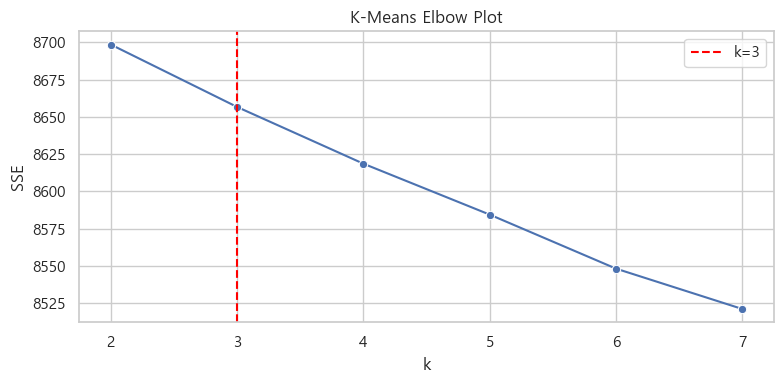

In [13]:
# =========================================
# 셀 16. 엘보우 플롯 시각화
# =========================================

plt.figure(figsize=(8, 4))

sns.lineplot(
    data=kmeans_elbow_df,
    x="k",
    y="sse",
    marker="o",
)

plt.axvline(
    KMEANS_N_CLUSTERS,
    color="red",
    linestyle="--",
    label=f"k={KMEANS_N_CLUSTERS}",
)

plt.title("K-Means Elbow Plot")
plt.xlabel("k")
plt.ylabel("SSE")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# =========================================
# 셀 17. 최종 K-Means 학습 및 문서별 cluster 할당
# =========================================

kmeans_model = KMeans(
    n_clusters=KMEANS_N_CLUSTERS,
    n_init=20,
    random_state=42,
)

analysis_df["cluster"] = kmeans_model.fit_predict(tfidf_matrix)

print("K-Means 학습 완료")
display(analysis_df[["section_name", "title", "cluster"]].head(10))

K-Means 학습 완료


,section_name,title,cluster
0,1구간 (2024.01~03),12월31일 아이가 어제 응급실 뺑뺑했어요,0
1,1구간 (2024.01~03),2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,0
2,1구간 (2024.01~03),몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 좋은 직업도 향후 평준화될 것 자식에게 어릴때 주식을 사주는 것이 중요해지고 있음,0
3,1구간 (2024.01~03),부끄러운 얘기지만 치과는 여러 곳 가보세요,0
4,1구간 (2024.01~03),의대 증원 관련 기사입니다,2
5,1구간 (2024.01~03),의료계 충격 보건복지부 차관의 망언에 대한 전국광역시도의사회장협의회의 강력한 반발,0
6,1구간 (2024.01~03),입시정보 2028 대입 개편안 미적분 현 미적분 기하 수능 제외 대학별 고사 증가 예상 조선일보,2
7,1구간 (2024.01~03),지혜로운 자는 명문대 학벌추구 하지마라 11 의약대 정원 증원하라,0
8,1구간 (2024.01~03),2023 교육 부분 10대 뉴스 노마스크 등교 챗GPT 글로컬대학 디지털교과서 첨단학과 공교육 강화 의대 정원 증원 교권 문제 디지털 새싹 대입제도 개편,2
9,1구간 (2024.01~03),2024 인서울 주요대학 수시전형 결과에 대한 단상 1 학생부 교과전형을 중심으로,2


In [15]:
# =========================================
# 셀 18. 군집별 상위 키워드 추출
# =========================================

tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

kmeans_top_terms_df = extract_top_terms(
    weights=kmeans_model.cluster_centers_,
    feature_names=tfidf_feature_names,
    item_name="cluster",
    top_n=TOP_N_WORDS,
)

# 군집별 문서 수도 같이 붙여서 해석을 쉽게 만든다.
cluster_size_df = (
    analysis_df["cluster"]
    .value_counts()
    .sort_index()
    .rename("cluster_size")
)

kmeans_top_terms_df = kmeans_top_terms_df.merge(
    cluster_size_df,
    left_on="cluster",
    right_index=True,
    how="left",
)

save_csv_utf8(
    kmeans_top_terms_df,
    KMEANS_DIR / "kmeans_cluster_top_terms.csv"
)

display(kmeans_top_terms_df.sort_values(["cluster", "rank"]).head(45))

,cluster,rank,keyword,weight,cluster_size
0,0,1,간호사,0.013237,5934
1,0,2,사직,0.012894,5934
2,0,3,전문의,0.012646,5934
3,0,4,주장,0.012152,5934
4,0,5,수가,0.012101,5934
5,0,6,치료,0.012001,5934
6,0,7,사태,0.011878,5934
7,0,8,단체,0.011575,5934
8,0,9,면허,0.011016,5934
9,0,10,공공,0.010918,5934


In [16]:
# =========================================
# 셀 19. 문서별 cluster 결과 저장
# =========================================

kmeans_doc_df = analysis_df[
    ["title", "date", "section", "section_name", "like", "comment_cnt", "cluster"]
].copy()

save_csv_utf8(
    kmeans_doc_df,
    KMEANS_DIR / "kmeans_doc_assignments.csv"
)

display(kmeans_doc_df.head())

,title,date,section,section_name,like,comment_cnt,cluster
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,0
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,0
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 좋은 직업도 향후 평준화될 것 자식에게 어릴때 주식을 사주는 것이 중요해지고 있음,2024-01-01,1,1구간 (2024.01~03),14,4,0
3,부끄러운 얘기지만 치과는 여러 곳 가보세요,2024-01-01,1,1구간 (2024.01~03),6,5,0
4,의대 증원 관련 기사입니다,2024-01-01,1,1구간 (2024.01~03),0,4,2


In [17]:
# =========================================
# 셀 20. 구간별 K-Means 군집 비율 계산
# =========================================

kmeans_section_distribution = build_section_ratio_table(
    kmeans_doc_df,
    value_col="cluster"
)

save_csv_utf8(
    kmeans_section_distribution,
    KMEANS_DIR / "kmeans_section_distribution.csv"
)

display(kmeans_section_distribution.sort_values(["section", "cluster"]))

,section,section_name,cluster,doc_count,section_total,ratio
0,1,1구간 (2024.01~03),0,1826,2289,0.797728
1,1,1구간 (2024.01~03),1,72,2289,0.031455
2,1,1구간 (2024.01~03),2,391,2289,0.170817
3,2,2구간 (2024.04~06),0,1634,2413,0.677165
4,2,2구간 (2024.04~06),1,62,2413,0.025694
5,2,2구간 (2024.04~06),2,717,2413,0.297140
6,3,3구간 (2024.07~12),0,1787,3011,0.593491
7,3,3구간 (2024.07~12),1,97,3011,0.032215
8,3,3구간 (2024.07~12),2,1127,3011,0.374294
9,4,4구간 (2025.01~06),0,687,1229,0.558991


cluster,0,1,2
section_name,,,
1구간 (2024.01~03),0.798,0.031,0.171
2구간 (2024.04~06),0.677,0.026,0.297
3구간 (2024.07~12),0.593,0.032,0.374
4구간 (2025.01~06),0.559,0.063,0.378


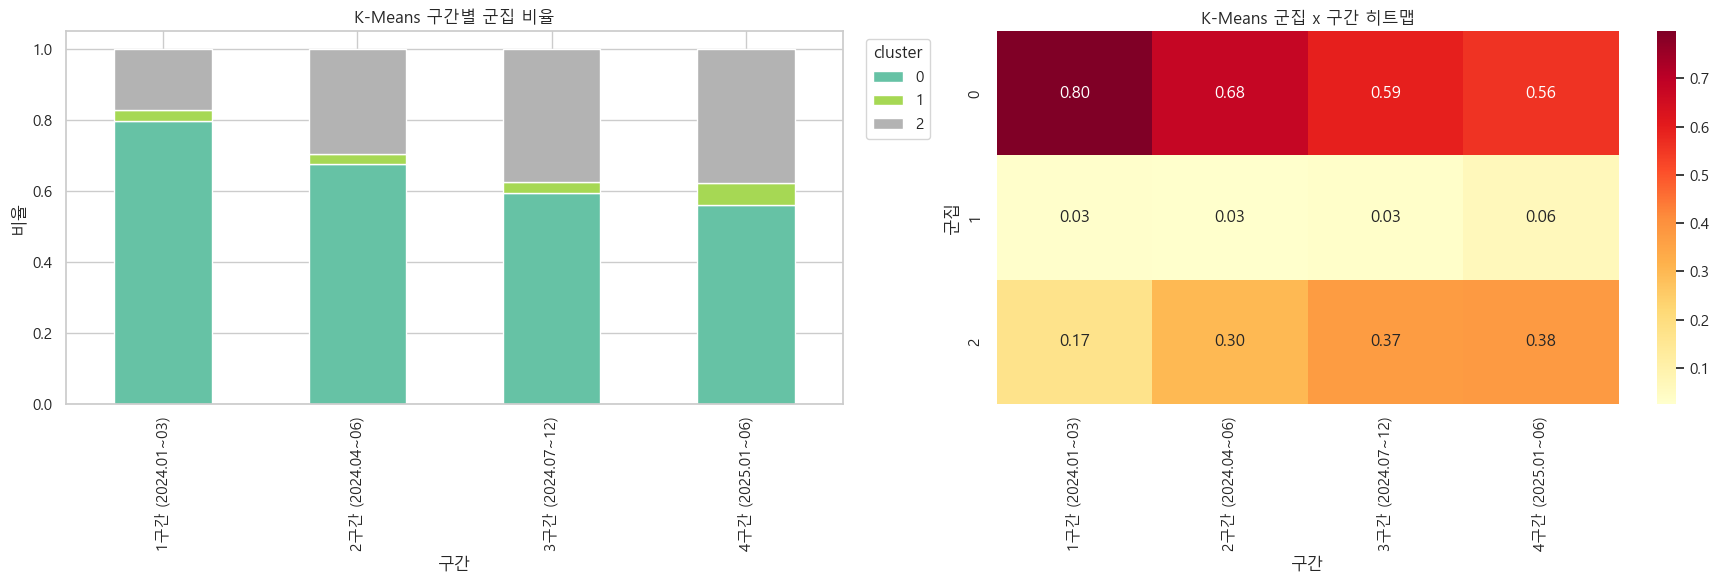

In [18]:
# =========================================
# 셀 21. K-Means 구간별 분포 시각화
# =========================================

kmeans_pivot = (
    kmeans_section_distribution
    .pivot(index="section_name", columns="cluster", values="ratio")
    .reindex(index=SECTION_ORDER)
    .reindex(columns=range(KMEANS_N_CLUSTERS))
    .fillna(0)
)

display(kmeans_pivot.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 왼쪽: 누적 막대그래프
kmeans_pivot.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="Set2",
)
axes[0].set_title("K-Means 구간별 군집 비율")
axes[0].set_xlabel("구간")
axes[0].set_ylabel("비율")
axes[0].legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 오른쪽: 히트맵
sns.heatmap(
    kmeans_pivot.T,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    ax=axes[1],
)
axes[1].set_title("K-Means 군집 x 구간 히트맵")
axes[1].set_xlabel("구간")
axes[1].set_ylabel("군집")

plt.tight_layout()
plt.show()

## 4. LDA 토픽 모델링

계획서에 따라 전체 문서를 기준으로 단일 LDA 모델을 학습한다.

- 벡터화: `CountVectorizer(min_df=5, max_df=0.85)`
- 토픽 수: `5개`
- 목적: 각 문서의 dominant topic을 구한 뒤 구간별 비율 변화를 비교

In [19]:
# =========================================
# 셀 23. LDA용 Count 벡터화
# =========================================

count_vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.85,
)

count_matrix = count_vectorizer.fit_transform(analysis_df["doc_text_filtered"])

print("Count matrix shape:", count_matrix.shape)

Count matrix shape: (8942, 18164)


In [22]:
# =========================================
# 셀 24. LDA 모델 학습 
# =========================================

import io
import re
import sys
import contextlib
from tqdm.auto import tqdm

class TqdmStdout(io.TextIOBase):
    """
    sklearn LDA의 verbose 출력에서
    'iteration: x of max_iter: y' 패턴을 읽어 tqdm을 갱신한다.
    """
    def __init__(self, original_stdout, pbar):
        self.original_stdout = original_stdout
        self.pbar = pbar
        self.last_iter = 0
        self.pattern = re.compile(r"iteration:\s*(\d+)\s*of\s*max_iter:\s*(\d+)", re.IGNORECASE)

    def write(self, text):
        # 원래 출력도 그대로 보이게 유지
        self.original_stdout.write(text)
        self.original_stdout.flush()

        # verbose 문자열 안에서 iteration 정보를 찾아 tqdm 업데이트
        for match in self.pattern.finditer(text):
            current_iter = int(match.group(1))
            total_iter = int(match.group(2))

            # 혹시 total이 다르면 tqdm total을 맞춰준다
            if self.pbar.total != total_iter:
                self.pbar.total = total_iter
                self.pbar.refresh()

            # 이전보다 진행된 만큼만 update
            if current_iter > self.last_iter:
                self.pbar.update(current_iter - self.last_iter)
                self.last_iter = current_iter

        return len(text)

    def flush(self):
        self.original_stdout.flush()


lda_model = LatentDirichletAllocation(
    n_components=LDA_N_TOPICS,
    learning_method="batch",
    random_state=42,
    max_iter=20,
    verbose=1,   # 내부 iteration 로그를 출력하게 함
)

with tqdm(
    total=lda_model.max_iter,
    desc="LDA 학습 진행률",
    unit="iter"
) as pbar:
    tqdm_stdout = TqdmStdout(sys.stdout, pbar)

    with contextlib.redirect_stdout(tqdm_stdout):
        doc_topic_matrix = lda_model.fit_transform(count_matrix)

    # 혹시 마지막 iteration 로그가 tqdm에 완전히 반영되지 않았으면 마저 채움
    if pbar.n < pbar.total:
        pbar.update(pbar.total - pbar.n)

print("LDA 학습 완료")
print("doc_topic_matrix shape:", doc_topic_matrix.shape)


LDA 학습 진행률:   0%|          | 0/20 [00:00<?, ?iter/s]

iteration: 1 of max_iter: 20
iteration: 2 of max_iter: 20
iteration: 3 of max_iter: 20
iteration: 4 of max_iter: 20
iteration: 5 of max_iter: 20
iteration: 6 of max_iter: 20
iteration: 7 of max_iter: 20
iteration: 8 of max_iter: 20
iteration: 9 of max_iter: 20
iteration: 10 of max_iter: 20
iteration: 11 of max_iter: 20
iteration: 12 of max_iter: 20
iteration: 13 of max_iter: 20
iteration: 14 of max_iter: 20
iteration: 15 of max_iter: 20
iteration: 16 of max_iter: 20
iteration: 17 of max_iter: 20
iteration: 18 of max_iter: 20
iteration: 19 of max_iter: 20
iteration: 20 of max_iter: 20
LDA 학습 완료
doc_topic_matrix shape: (8942, 5)


In [33]:
%pip install pyLDAvis

Note: you may need to restart the kernel to use updated packages.


In [34]:
# =========================================
# 셀 24-2. pyLDAvis용 데이터 준비
# =========================================

import pyLDAvis

# 노트북 안에서 바로 보이도록 설정
pyLDAvis.enable_notebook()

# 1. topic-term 분포
# sklearn LDA의 components_는 확률이 아니라 가중치 성격이므로
# topic별 합이 1이 되도록 정규화해 준다.
topic_term_dists = lda_model.components_ / lda_model.components_.sum(axis=1)[:, None]

# 2. doc-topic 분포
# fit_transform 결과도 거의 확률분포지만,
# 혹시를 대비해 행 기준으로 다시 정규화한다.
doc_topic_dists = doc_topic_matrix / doc_topic_matrix.sum(axis=1, keepdims=True)

# 3. 문서 길이
# 각 문서의 전체 토큰 수
doc_lengths = np.asarray(count_matrix.sum(axis=1)).ravel()

# 4. vocabulary
vocab = count_vectorizer.get_feature_names_out()

# 5. 전체 말뭉치에서 각 단어의 등장 빈도
term_frequency = np.asarray(count_matrix.sum(axis=0)).ravel()

print("topic_term_dists shape:", topic_term_dists.shape)
print("doc_topic_dists shape:", doc_topic_dists.shape)
print("doc_lengths shape:", doc_lengths.shape)
print("vocab length:", len(vocab))
print("term_frequency shape:", term_frequency.shape)

topic_term_dists shape: (5, 18164)
doc_topic_dists shape: (8942, 5)
doc_lengths shape: (8942,)
vocab length: 18164
term_frequency shape: (18164,)


In [36]:
# =========================================
# 셀 24-3. pyLDAvis 시각화 생성
# =========================================

lda_vis = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=vocab,
    term_frequency=term_frequency,
    R=30,                   # 오른쪽 막대에 보여줄 단어 수
    mds="pcoa",             # 토픽 거리 맵 차원축소 방식
    sort_topics=False,      # sklearn topic 번호 유지
    n_jobs=1,               # 핵심: 병렬 처리 끄기
)

pyLDAvis.display(lda_vis)

In [37]:
# =========================================
# 셀 24-4. HTML로 저장
# =========================================

pyLDAvis.save_html(lda_vis, str(LDA_DIR / "lda_pyldavis.html"))
print("저장 완료:", LDA_DIR / "lda_pyldavis.html")

저장 완료: C:\Increase-in-medical-school-seats\outputs\pipeline\lda\lda_pyldavis.html


문서별 토픽 확률 합 - 최소값: 0.9999999999999996
문서별 토픽 확률 합 - 최대값: 1.0000000000000004
문서별 토픽 확률 합 - 평균값: 1.0


,topic,doc_count
0,0,1067
1,1,2729
2,2,1742
3,3,2438
4,4,966


C:\Users\이서연\AppData\Local\Temp\ipykernel_25736\3583810671.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dominant_topic_df, x="topic", y="doc_count", palette="tab10")


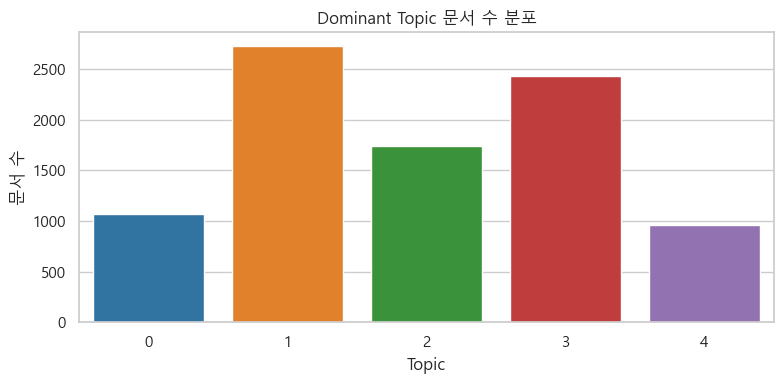

,topic_0,topic_1,topic_2,topic_3,topic_4
0,0.295947,0.000303,0.027655,0.675791,0.000304
1,0.214062,0.075546,0.420738,0.000881,0.288772
2,0.239734,0.000635,0.000628,0.255743,0.503260
3,0.565294,0.001057,0.155619,0.276959,0.001071
4,0.006447,0.874357,0.006540,0.106229,0.006427


In [23]:
# =========================================
# 셀 25. LDA 학습 결과 빠른 점검
# =========================================

# 각 문서의 토픽 확률 합은 1에 가까워야 함
row_sum = doc_topic_matrix.sum(axis=1)

print("문서별 토픽 확률 합 - 최소값:", row_sum.min())
print("문서별 토픽 확률 합 - 최대값:", row_sum.max())
print("문서별 토픽 확률 합 - 평균값:", row_sum.mean())

# 문서별 대표 토픽 확인
dominant_topic = doc_topic_matrix.argmax(axis=1)
dominant_topic_df = pd.Series(dominant_topic).value_counts().sort_index().reset_index()
dominant_topic_df.columns = ["topic", "doc_count"]

display(dominant_topic_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=dominant_topic_df, x="topic", y="doc_count", palette="tab10")
plt.title("Dominant Topic 문서 수 분포")
plt.xlabel("Topic")
plt.ylabel("문서 수")
plt.tight_layout()
plt.show()

display(pd.DataFrame(doc_topic_matrix, columns=[f"topic_{i}" for i in range(LDA_N_TOPICS)]).head())

In [24]:
# =========================================
# 셀 26. 토픽별 상위 키워드 추출
# =========================================

count_feature_names = np.array(count_vectorizer.get_feature_names_out())

lda_topic_keywords_df = extract_top_terms(
    weights=lda_model.components_,
    feature_names=count_feature_names,
    item_name="topic",
    top_n=TOP_N_WORDS,
)

save_csv_utf8(
    lda_topic_keywords_df,
    LDA_DIR / "lda_topic_keywords.csv"
)

display(lda_topic_keywords_df.sort_values(["topic", "rank"]).head(30))

,topic,rank,keyword,weight
0,0,1,재생,2152.857352
1,0,2,마음,1308.980824
2,0,3,엄마,1247.754611
3,0,4,부모,1178.339165
4,0,5,친구,1060.945366
5,0,6,경험,1009.983047
6,0,7,직업,997.721773
7,0,8,사용,970.530676
8,0,9,생활,934.825693
9,0,10,고민,879.716089


In [25]:
# =========================================
# 셀 27. 문서별 토픽 분포와 dominant topic 저장
# =========================================

topic_cols = [f"topic_{i}" for i in range(LDA_N_TOPICS)]

lda_doc_df = analysis_df[
    ["title", "date", "section", "section_name", "like", "comment_cnt"]
].copy()

# 각 문서가 각 토픽에 얼마나 속하는지 확률값을 열로 추가
lda_doc_df[topic_cols] = doc_topic_matrix

# 가장 높은 확률을 가진 토픽을 대표 토픽으로 사용
lda_doc_df["dominant_topic"] = doc_topic_matrix.argmax(axis=1)

save_csv_utf8(
    lda_doc_df,
    LDA_DIR / "lda_doc_topic_distribution.csv"
)

display(lda_doc_df.head())

,title,date,section,section_name,like,comment_cnt,topic_0,topic_1,topic_2,topic_3,topic_4,dominant_topic
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,0.295947,0.000303,0.027655,0.675791,0.000304,3
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,0.214062,0.075546,0.420738,0.000881,0.288772,2
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 좋은 직업도 향후 평준화될 것 자식에게 어릴때 주식을 사주는 것이 중요해지고 있음,2024-01-01,1,1구간 (2024.01~03),14,4,0.239734,0.000635,0.000628,0.255743,0.503260,4
3,부끄러운 얘기지만 치과는 여러 곳 가보세요,2024-01-01,1,1구간 (2024.01~03),6,5,0.565294,0.001057,0.155619,0.276959,0.001071,0
4,의대 증원 관련 기사입니다,2024-01-01,1,1구간 (2024.01~03),0,4,0.006447,0.874357,0.006540,0.106229,0.006427,1


In [26]:
# =========================================
# 셀 28. 구간별 LDA 토픽 비율 계산
# =========================================

lda_section_distribution = build_section_ratio_table(
    lda_doc_df,
    value_col="dominant_topic"
)

save_csv_utf8(
    lda_section_distribution,
    LDA_DIR / "lda_section_distribution.csv"
)

display(lda_section_distribution.sort_values(["section", "dominant_topic"]))


,section,section_name,dominant_topic,doc_count,section_total,ratio
0,1,1구간 (2024.01~03),0,309,2289,0.134993
1,1,1구간 (2024.01~03),1,375,2289,0.163827
2,1,1구간 (2024.01~03),2,568,2289,0.248143
3,1,1구간 (2024.01~03),3,732,2289,0.319790
4,1,1구간 (2024.01~03),4,305,2289,0.133246
5,2,2구간 (2024.04~06),0,306,2413,0.126813
6,2,2구간 (2024.04~06),1,673,2413,0.278906
7,2,2구간 (2024.04~06),2,515,2413,0.213427
8,2,2구간 (2024.04~06),3,604,2413,0.250311
9,2,2구간 (2024.04~06),4,315,2413,0.130543


dominant_topic,0,1,2,3,4
section_name,,,,,
1구간 (2024.01~03),0.135,0.164,0.248,0.320,0.133
2구간 (2024.04~06),0.127,0.279,0.213,0.250,0.131
3구간 (2024.07~12),0.109,0.389,0.160,0.250,0.091
4구간 (2025.01~06),0.100,0.414,0.143,0.284,0.059


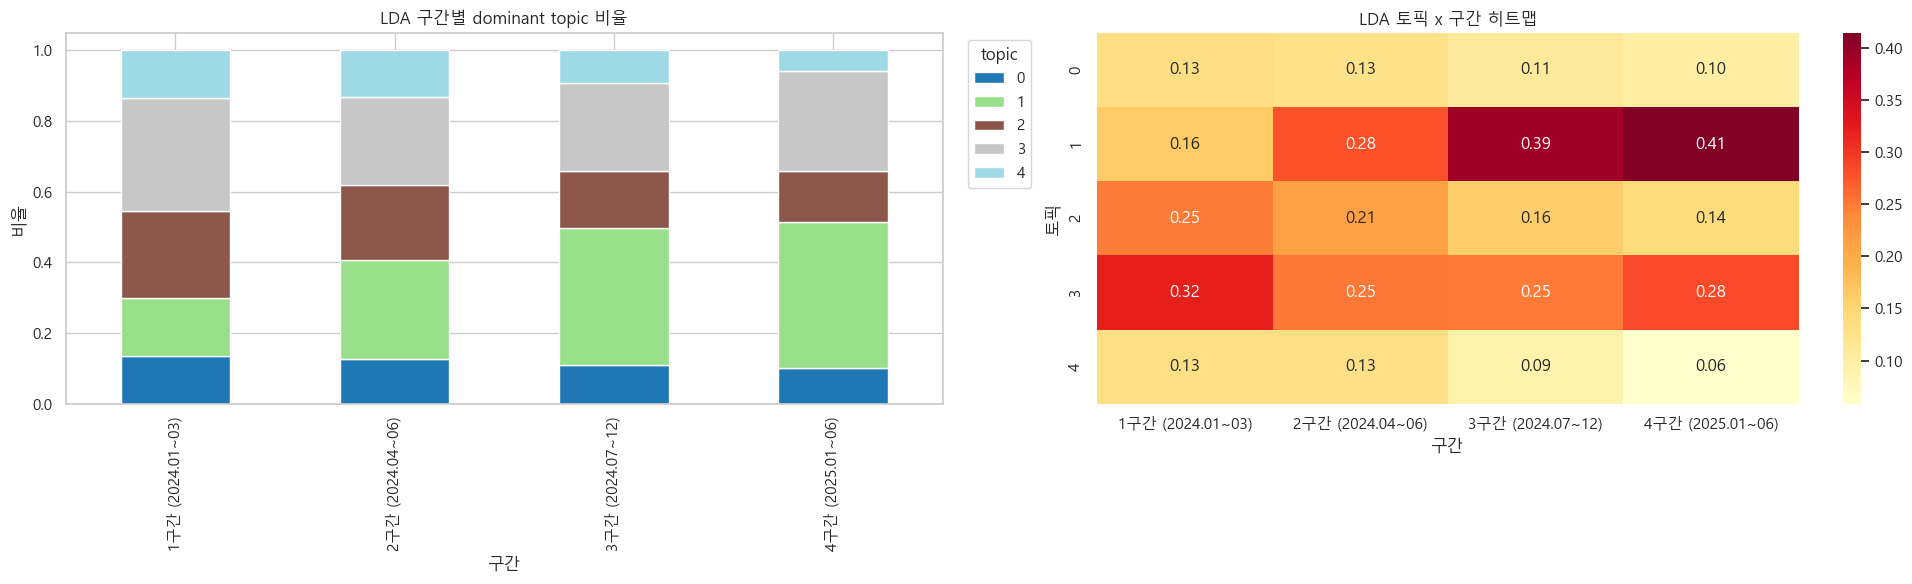

In [27]:
# =========================================
# 셀 28. LDA 구간별 분포 시각화
# =========================================

lda_pivot = (
    lda_section_distribution
    .pivot(index="section_name", columns="dominant_topic", values="ratio")
    .reindex(index=SECTION_ORDER)
    .reindex(columns=range(LDA_N_TOPICS))
    .fillna(0)
)

display(lda_pivot.round(3))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 왼쪽: 누적 막대그래프
lda_pivot.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20",
)
axes[0].set_title("LDA 구간별 dominant topic 비율")
axes[0].set_xlabel("구간")
axes[0].set_ylabel("비율")
axes[0].legend(title="topic", bbox_to_anchor=(1.02, 1), loc="upper left")

# 오른쪽: 히트맵
sns.heatmap(
    lda_pivot.T,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    ax=axes[1],
)
axes[1].set_title("LDA 토픽 x 구간 히트맵")
axes[1].set_xlabel("구간")
axes[1].set_ylabel("토픽")

plt.tight_layout()
plt.show()

## 5. 군집 / 토픽 해석 준비

이 단계에서는 상위 키워드를 바탕으로  
각 군집과 토픽에 사람이 읽을 수 있는 해석 라벨을 붙인다.

처음에는 기본 라벨(`Cluster 0`, `Topic 0`)로 두고,  
키워드를 확인한 뒤 아래 딕셔너리만 수정하면 된다.

In [28]:
# =========================================
# 셀 30. 군집 / 토픽 키워드 묶음 확인
# =========================================

cluster_keyword_summary = (
    kmeans_top_terms_df.sort_values(["cluster", "rank"])
    .groupby("cluster")["keyword"]
    .apply(list)
)

topic_keyword_summary = (
    lda_topic_keywords_df.sort_values(["topic", "rank"])
    .groupby("topic")["keyword"]
    .apply(list)
)

print("[K-Means 군집별 키워드]")
display(cluster_keyword_summary)

print("[LDA 토픽별 키워드]")
display(topic_keyword_summary)

[K-Means 군집별 키워드]


cluster
0     [간호사, 사직, 전문의, 주장, 수가, 치료, 사태, 단체, 면허, 공공, 대책, 지지, 응급, 현장, 시스템]
1       [규칙, 게시, 금지, 제한, 이용, 로물콘, 회원, 개진, 모욕, 영리, 비난, 허용, 삭제, 범위, 질문]
2    [재수, 설명회, 학종, 약대, 컨설팅, 국어, 점수, 학습, 편입, 자연, 원서, 학부모, 탐구, 과탐, 연세대]
Name: keyword, dtype: object

[LDA 토픽별 키워드]


topic
0         [재생, 마음, 엄마, 부모, 친구, 경험, 직업, 사용, 생활, 고민, 기본, 분야, 다양, 졸업, 설정]
1     [재수, 점수, 학습, 설명회, 자연, 국어, 컨설팅, 약대, 학부모, 학종, 탐구, 연세대, 추천, 학부, 원서]
2       [사직, 위원회, 단체, 현장, 제출, 기관, 복귀, 응급, 대책, 갈등, 방안, 간호사, 우려, 반발, 국회]
3    [수가, 지지, 주장, 민주당, 우리나라, 정권, 선거, 인구, 전문의, 민영, 시스템, 치료, 사태, 급여, 책임]
4       [반도체, 투자, 중국, 금리, 사업, 국내, 개발, 최대, 주식, 기술, 가격, 전기, 주가, 전망, 부동산]
Name: keyword, dtype: object

In [29]:
# =========================================
# 셀 31. 해석용 라벨 수동 지정
# =========================================

# 처음 실행할 때는 기본 라벨을 사용한다.
# 키워드를 본 뒤 아래 내용을 직접 수정하면 된다.

cluster_label_map = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
}

topic_label_map = {
    0: "Topic 0",
    1: "Topic 1",
    2: "Topic 2",
    3: "Topic 3",
    4: "Topic 4",
}

# 예시:
# cluster_label_map = {
#     0: "의료 현장 우려형",
#     1: "정책·교육 논쟁형",
#     2: "사회·경제 파급형",
# }
#
# topic_label_map = {
#     0: "정책/제도",
#     1: "의료 현장",
#     2: "입시/교육",
#     3: "정치/사회",
#     4: "경제/투자",
# }

kmeans_doc_df["cluster_label"] = kmeans_doc_df["cluster"].map(cluster_label_map)
lda_doc_df["topic_label"] = lda_doc_df["dominant_topic"].map(topic_label_map)

print("라벨 적용 완료")
display(kmeans_doc_df.head(3))
display(lda_doc_df.head(3))

라벨 적용 완료


,title,date,section,section_name,like,comment_cnt,cluster,cluster_label
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,0,Cluster 0
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,0,Cluster 0
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 좋은 직업도 향후 평준화될 것 자식에게 어릴때 주식을 사주는 것이 중요해지고 있음,2024-01-01,1,1구간 (2024.01~03),14,4,0,Cluster 0


,title,date,section,section_name,like,comment_cnt,topic_0,topic_1,topic_2,topic_3,topic_4,dominant_topic,topic_label
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,0.295947,0.000303,0.027655,0.675791,0.000304,3,Topic 3
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,0.214062,0.075546,0.420738,0.000881,0.288772,2,Topic 2
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 좋은 직업도 향후 평준화될 것 자식에게 어릴때 주식을 사주는 것이 중요해지고 있음,2024-01-01,1,1구간 (2024.01~03),14,4,0.239734,0.000635,0.000628,0.255743,0.503260,4,Topic 4


## 6. 반응 지표 시각화

계획서의 시각화 방향에 맞춰  
좋아요 수와 댓글 수의 분포를 박스플롯으로 확인한다.

- 군집별 좋아요 분포
- 군집별 댓글 수 분포
- 토픽별 좋아요 분포
- 토픽별 댓글 수 분포
- 구간별 좋아요 / 댓글 분포

C:\Users\이서연\AppData\Local\Temp\ipykernel_25736\290104437.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\이서연\AppData\Local\Temp\ipykernel_25736\290104437.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\이서연\AppData\Local\Temp\ipykernel_25736\290104437.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\이서연\AppData\Local\Temp\ipykernel_25736\290104437.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

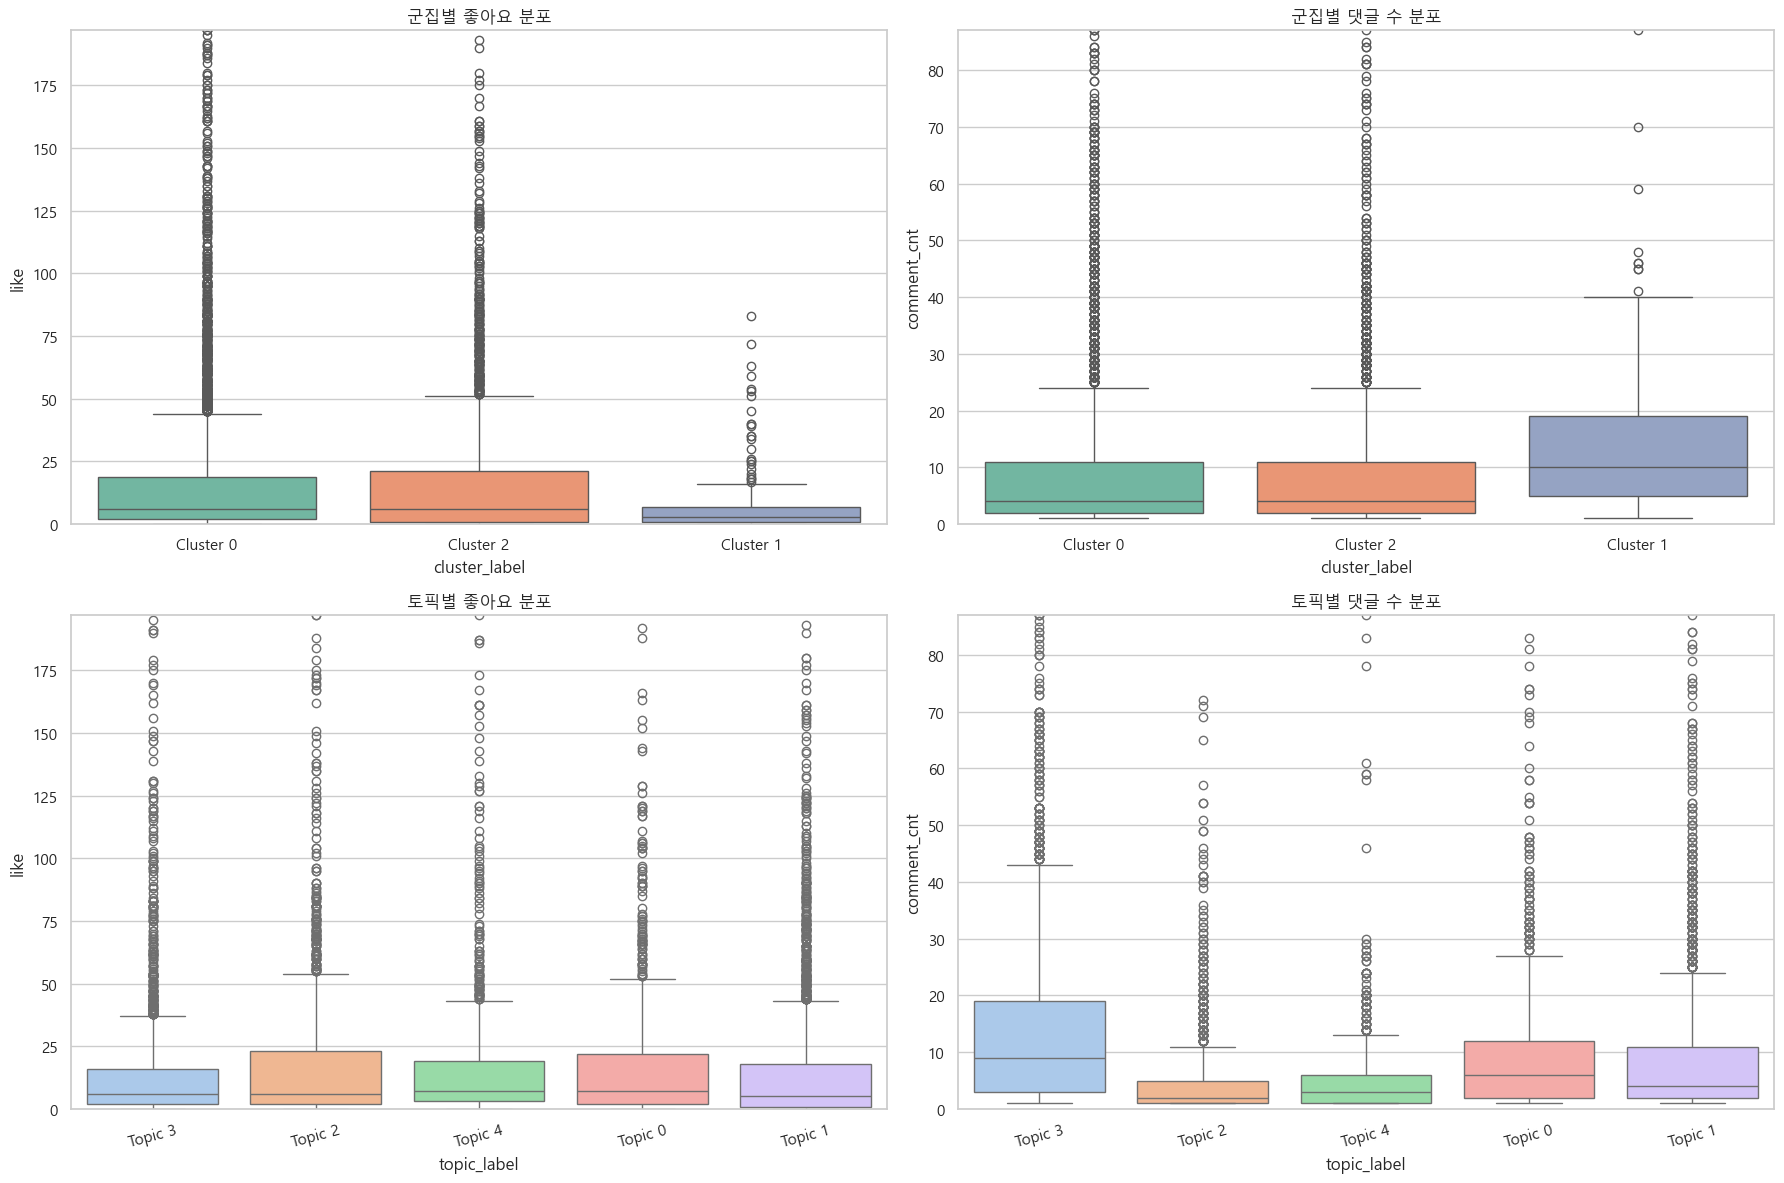

In [30]:
# =========================================
# 셀 33. 군집 / 토픽별 반응 지표 박스플롯
# =========================================

cluster_ylim_like = max(1, kmeans_doc_df["like"].quantile(0.99))
cluster_ylim_comment = max(1, kmeans_doc_df["comment_cnt"].quantile(0.99))

topic_ylim_like = max(1, lda_doc_df["like"].quantile(0.99))
topic_ylim_comment = max(1, lda_doc_df["comment_cnt"].quantile(0.99))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(
    data=kmeans_doc_df,
    x="cluster_label",
    y="like",
    ax=axes[0, 0],
    palette="Set2",
)
axes[0, 0].set_title("군집별 좋아요 분포")
axes[0, 0].set_ylim(0, cluster_ylim_like)

sns.boxplot(
    data=kmeans_doc_df,
    x="cluster_label",
    y="comment_cnt",
    ax=axes[0, 1],
    palette="Set2",
)
axes[0, 1].set_title("군집별 댓글 수 분포")
axes[0, 1].set_ylim(0, cluster_ylim_comment)

sns.boxplot(
    data=lda_doc_df,
    x="topic_label",
    y="like",
    ax=axes[1, 0],
    palette="pastel",
)
axes[1, 0].set_title("토픽별 좋아요 분포")
axes[1, 0].set_ylim(0, topic_ylim_like)
axes[1, 0].tick_params(axis="x", rotation=15)

sns.boxplot(
    data=lda_doc_df,
    x="topic_label",
    y="comment_cnt",
    ax=axes[1, 1],
    palette="pastel",
)
axes[1, 1].set_title("토픽별 댓글 수 분포")
axes[1, 1].set_ylim(0, topic_ylim_comment)
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

C:\Users\이서연\AppData\Local\Temp\ipykernel_25736\3925816409.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\이서연\AppData\Local\Temp\ipykernel_25736\3925816409.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


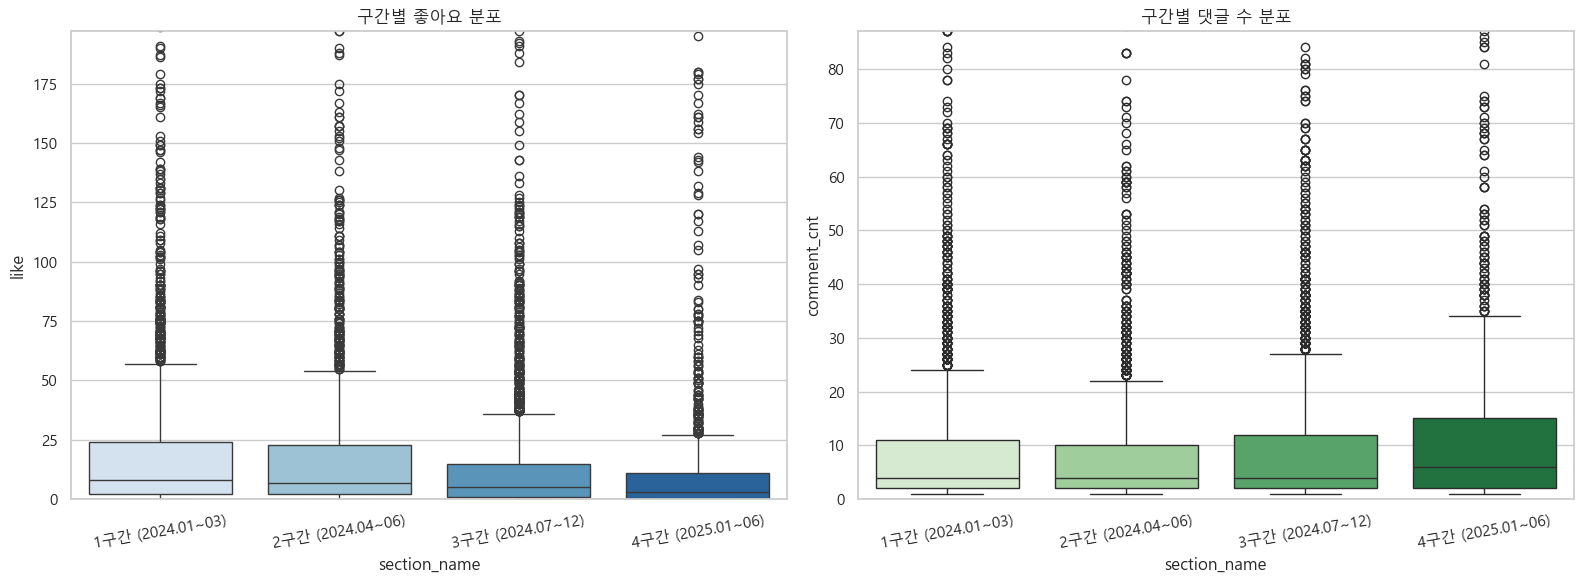

In [31]:
# =========================================
# 셀 34. 구간별 반응 지표 박스플롯
# =========================================

section_ylim_like = max(1, analysis_df["like"].quantile(0.99))
section_ylim_comment = max(1, analysis_df["comment_cnt"].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=analysis_df,
    x="section_name",
    y="like",
    order=SECTION_ORDER,
    ax=axes[0],
    palette="Blues",
)
axes[0].set_title("구간별 좋아요 분포")
axes[0].set_ylim(0, section_ylim_like)
axes[0].tick_params(axis="x", rotation=10)

sns.boxplot(
    data=analysis_df,
    x="section_name",
    y="comment_cnt",
    order=SECTION_ORDER,
    ax=axes[1],
    palette="Greens",
)
axes[1].set_title("구간별 댓글 수 분포")
axes[1].set_ylim(0, section_ylim_comment)
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

## 7. 선택 분석: 구간별 TF-IDF 키워드 히트맵

전체 학습 기반 K-Means / LDA가 큰 담론 구조를 보여준다면,  
구간별 TF-IDF는 각 시기에 특이하게 부상한 키워드를 보완적으로 보여준다.

section_name,1구간 (2024.01~03),2구간 (2024.04~06),3구간 (2024.07~12),4구간 (2025.01~06)
keyword,,,,
간호사,0.084879,0.000000,0.074629,0.0
국회,0.000000,0.071957,0.081347,0.0
근무,0.083505,0.000000,0.000000,0.0
단체,0.081597,0.000000,0.000000,0.0
면허,0.092588,0.000000,0.000000,0.0


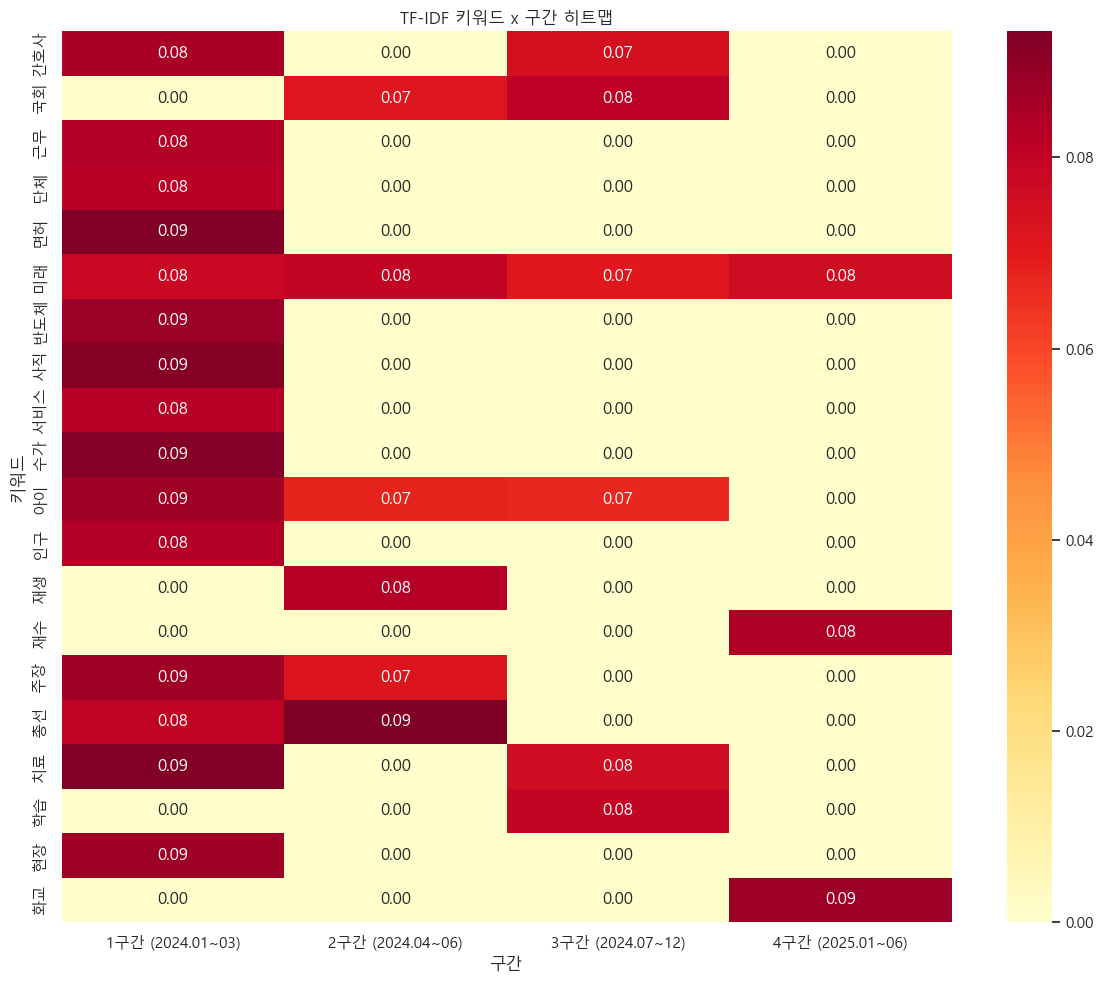

In [32]:
# =========================================
# 셀 36. 기존 TF-IDF 결과 불러와 키워드 x 구간 히트맵 그리기
# =========================================

tfidf_path = TFIDF_DIR / "tfidf_top_terms_by_section.csv"

if tfidf_path.exists():
    tfidf_by_section = pd.read_csv(tfidf_path)

    # section 숫자를 다시 구간명으로 매핑
    tfidf_by_section["section"] = pd.to_numeric(tfidf_by_section["section"], errors="coerce")
    tfidf_by_section["section_name"] = tfidf_by_section["section"].map(SECTION_NAME_MAP)

    # 전체 구간에서 중요도가 높은 키워드 20개만 추출
    top_keywords = (
        tfidf_by_section.groupby("keyword")["tfidf"]
        .max()
        .sort_values(ascending=False)
        .head(20)
        .index
    )

    tfidf_heatmap_df = (
        tfidf_by_section[tfidf_by_section["keyword"].isin(top_keywords)]
        .pivot(index="keyword", columns="section_name", values="tfidf")
        .reindex(columns=SECTION_ORDER)
        .fillna(0)
    )

    display(tfidf_heatmap_df.head())

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        tfidf_heatmap_df,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
    )
    plt.title("TF-IDF 키워드 x 구간 히트맵")
    plt.xlabel("구간")
    plt.ylabel("키워드")
    plt.tight_layout()
    plt.show()

else:
    print(f"파일이 없습니다: {tfidf_path}")


## 8. 해석 메모

최종 해석 시 아래 질문에 답하는 방식으로 정리하면 된다.

### K-Means
- 어떤 군집이 1구간에서 가장 강했는가?
- 시간이 지나며 어떤 군집 비중이 감소하거나 증가했는가?
- 특정 군집은 좋아요 / 댓글 반응이 상대적으로 높았는가?

### LDA
- 어떤 토픽이 각 구간의 dominant topic으로 자주 등장했는가?
- 구간 1에서 강했던 토픽이 구간 4에서 약화되었는가?
- 특정 토픽은 논쟁성(comment_cnt)이 더 높은가?

### TF-IDF 보완
- 특정 시기만의 고유 키워드는 무엇인가?
- 전체 학습 모델에서 약하게 보였지만 TF-IDF에서 강하게 보이는 시기성 키워드는 무엇인가?